In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.datasets import cifar10

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
print("Downloading CIFAR-10 dataset...")

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)
print("Training labels     :", y_train.shape)
print("Testing labels      :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1369s 8us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape : (10000, 32, 32, 3)
Training labels     : (50000,)
Testing labels      : (10000,)


**Display CIFAR-10 sample images**

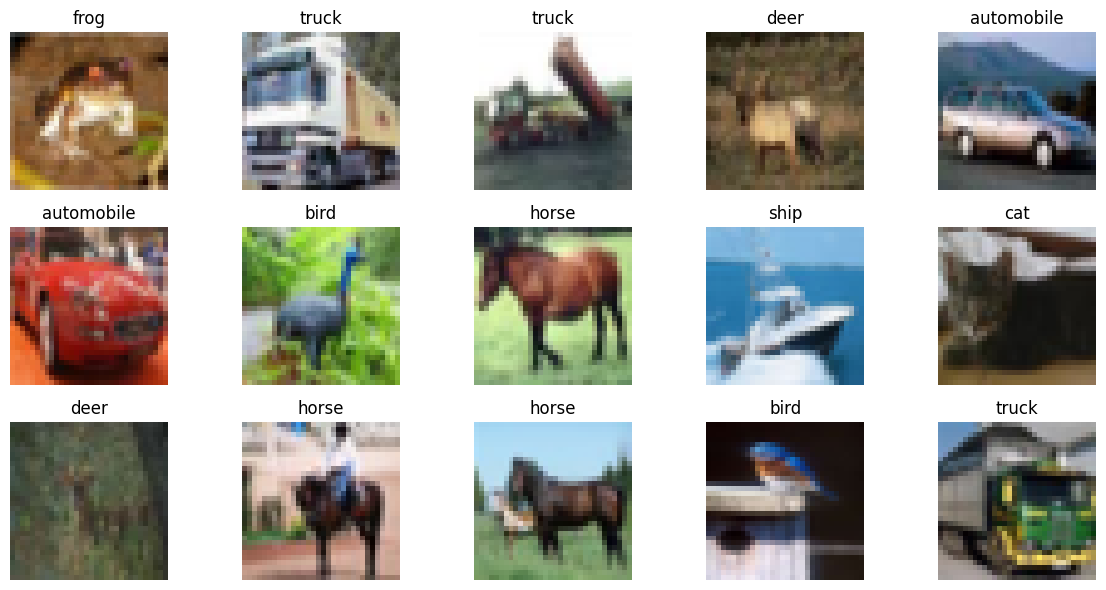

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

def preprocess_images(images):
    processed = []

    for img in images:
        # Convert RGB to grayscale
        gray = np.dot(img[..., :3], [0.299, 0.587, 0.114])

        # Resize from 32x32 to 16x16
        resized = Image.fromarray(gray.astype(np.uint8)).resize(
            (16, 16),
            Image.Resampling.BILINEAR
        )

        processed.append(np.array(resized, dtype=np.float32))

    return np.array(processed)


start = time.time()

X_train_small = preprocess_images(X_train)
X_test_small = preprocess_images(X_test)

print("Preprocessing completed!")
print("Time:", round(time.time() - start, 2), "seconds")

print("New training shape:", X_train_small.shape)
print("New testing shape :", X_test_small.shape)

Preprocessing completed!
Time: 5.04 seconds
New training shape: (50000, 16, 16)
New testing shape : (10000, 16, 16)


In [ ]:
X_train_flat = X_train_small.reshape(X_train_small.shape[0], -1)
X_test_flat = X_test_small.reshape(X_test_small.shape[0], -1)

# Normalize pixel values from 0-255 to 0-1
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

print("Training feature shape:", X_train_flat.shape)
print("Testing feature shape :", X_test_flat.shape)

Training feature shape: (50000, 256)
Testing feature shape : (10000, 256)


In [ ]:
# Number of samples per class
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 100

def balanced_subset(X, y, samples_per_class):
    indices = []

    for c in range(10):
        class_indices = np.where(y == c)[0]
        selected = class_indices[:samples_per_class]
        indices.extend(selected)

    indices = np.array(indices)

    return X[indices], y[indices]


X_train_exp, y_train_exp = balanced_subset(
    X_train_flat,
    y_train,
    TRAIN_PER_CLASS
)

X_test_exp, y_test_exp = balanced_subset(
    X_test_flat,
    y_test,
    TEST_PER_CLASS
)

print("Experimental training set:", X_train_exp.shape)
print("Experimental testing set :", X_test_exp.shape)

Experimental training set: (5000, 256)
Experimental testing set : (1000, 256)


**KNN FROM SCRATCH**

Euclidean Distance

In [ ]:
def euclidean_distance(test_point, train_data):
    """
    Euclidean distance:
    sqrt(sum((x-y)^2))
    """

    distances = np.sqrt(
        np.sum((train_data - test_point) ** 2, axis=1)
    )

    return distances

Manhattan Distance

In [ ]:
def manhattan_distance(test_point, train_data):
    """
    Manhattan distance:
    sum(|x-y|)
    """

    distances = np.sum(
        np.abs(train_data - test_point),
        axis=1
    )

    return distances

Minkowski Distance

In [ ]:
def minkowski_distance(test_point, train_data, p=3):
    """
    Minkowski distance:
    (sum(|x-y|^p))^(1/p)
    """

    distances = np.sum(
        np.abs(train_data - test_point) ** p,
        axis=1
    ) ** (1 / p)

    return distances

Cosine Distance

In [ ]:
def cosine_distance(test_point, train_data):
    """
    Cosine distance = 1 - cosine similarity
    """

    test_norm = np.linalg.norm(test_point)
    train_norms = np.linalg.norm(train_data, axis=1)

    denominator = train_norms * test_norm

    numerator = np.dot(train_data, test_point)

    similarity = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0
    )

    distances = 1 - similarity

    return distances

Hamming Distance

In [ ]:
def hamming_distance(test_point, train_data):
    """
    Convert pixel values into binary values.
    Hamming distance = number of positions that differ.
    """

    test_binary = test_point >= 0.5
    train_binary = train_data >= 0.5

    distances = np.mean(
        train_binary != test_binary,
        axis=1
    )

    return distances





---
KNN prediction function

---




In [ ]:
def knn_predict(
    X_train,
    y_train,
    X_test,
    k,
    distance_metric
):
    predictions = []

    for i, test_point in enumerate(X_test):

        # Calculate distance from test point to every training point
        distances = distance_metric(
            test_point,
            X_train
        )

        # Get indices of k nearest neighbors
        nearest_indices = np.argpartition(
            distances,
            k
        )[:k]

        # Get their labels
        nearest_labels = y_train[nearest_indices]

        # Majority voting
        counts = np.bincount(
            nearest_labels,
            minlength=10
        )

        prediction = np.argmax(counts)

        predictions.append(prediction)

    return np.array(predictions)



---

Accuracy function

---



In [ ]:
def accuracy_score_manual(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)

    return correct / total


def evaluate_knn(
    X_train,
    y_train,
    X_test,
    y_test,
    k,
    distance_metric
):

    start = time.time()

    predictions = knn_predict(
        X_train,
        y_train,
        X_test,
        k,
        distance_metric
    )

    accuracy = accuracy_score_manual(
        y_test,
        predictions
    )

    elapsed = time.time() - start

    return accuracy, predictions, elapsed



---

Experiment with Different K Values

---



In [ ]:
distance_metrics = {
    "Euclidean": euclidean_distance,
    "Manhattan": manhattan_distance,
    "Minkowski": minkowski_distance,
    "Cosine": cosine_distance,
    "Hamming": hamming_distance
}

k_values = [1, 3, 5, 7, 9]

print("Distance metrics:")
for metric in distance_metrics:
    print("-", metric)

print("\nK values:", k_values)

Distance metrics:
- Euclidean
- Manhattan
- Minkowski
- Cosine
- Hamming

K values: [1, 3, 5, 7, 9]


In [ ]:
results = {}
all_predictions = {}

for metric_name, metric_function in distance_metrics.items():

    results[metric_name] = []
    all_predictions[metric_name] = {}

    print("\n" + "=" * 50)
    print("Distance Metric:", metric_name)
    print("=" * 50)

    for k in k_values:

        print("Running K =", k, "...", end=" ")

        accuracy, predictions, elapsed = evaluate_knn(
            X_train_exp,
            y_train_exp,
            X_test_exp,
            y_test_exp,
            k,
            metric_function
        )

        results[metric_name].append(accuracy)
        all_predictions[metric_name][k] = predictions

        print(
            "Accuracy:",
            round(accuracy * 100, 2),
            "%",
            "| Time:",
            round(elapsed, 2),
            "sec"
        )


Distance Metric: Euclidean
Running K = 1 ... Accuracy: 23.8 % | Time: 1.19 sec
Running K = 3 ... Accuracy: 22.6 % | Time: 0.89 sec
Running K = 5 ... Accuracy: 25.6 % | Time: 1.19 sec
Running K = 7 ... Accuracy: 26.7 % | Time: 0.88 sec
Running K = 9 ... Accuracy: 25.9 % | Time: 0.89 sec

Distance Metric: Manhattan
Running K = 1 ... Accuracy: 24.8 % | Time: 1.0 sec
Running K = 3 ... Accuracy: 23.2 % | Time: 1.02 sec
Running K = 5 ... Accuracy: 25.8 % | Time: 1.01 sec
Running K = 7 ... Accuracy: 27.0 % | Time: 1.18 sec
Running K = 9 ... Accuracy: 28.1 % | Time: 1.27 sec

Distance Metric: Minkowski
Running K = 1 ... Accuracy: 23.1 % | Time: 12.86 sec
Running K = 3 ... Accuracy: 20.5 % | Time: 12.85 sec
Running K = 5 ... Accuracy: 24.2 % | Time: 13.09 sec
Running K = 7 ... Accuracy: 22.6 % | Time: 12.92 sec
Running K = 9 ... Accuracy: 25.1 % | Time: 12.89 sec

Distance Metric: Cosine
Running K = 1 ... Accuracy: 27.3 % | Time: 0.89 sec
Running K = 3 ... Accuracy: 24.4 % | Time: 0.93 sec
Run

 **Display results as a table**

---



In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    index=[f"K={k}" for k in k_values]
)

print("\nAccuracy Results:")
display(
    results_df.round(4)
)


Accuracy Results:


,Euclidean,Manhattan,Minkowski,Cosine,Hamming
K=1,0.238,0.248,0.231,0.273,0.208
K=3,0.226,0.232,0.205,0.244,0.224
K=5,0.256,0.258,0.242,0.250,0.241
K=7,0.267,0.270,0.226,0.271,0.250
K=9,0.259,0.281,0.251,0.278,0.265


**Accuracy Visualization**

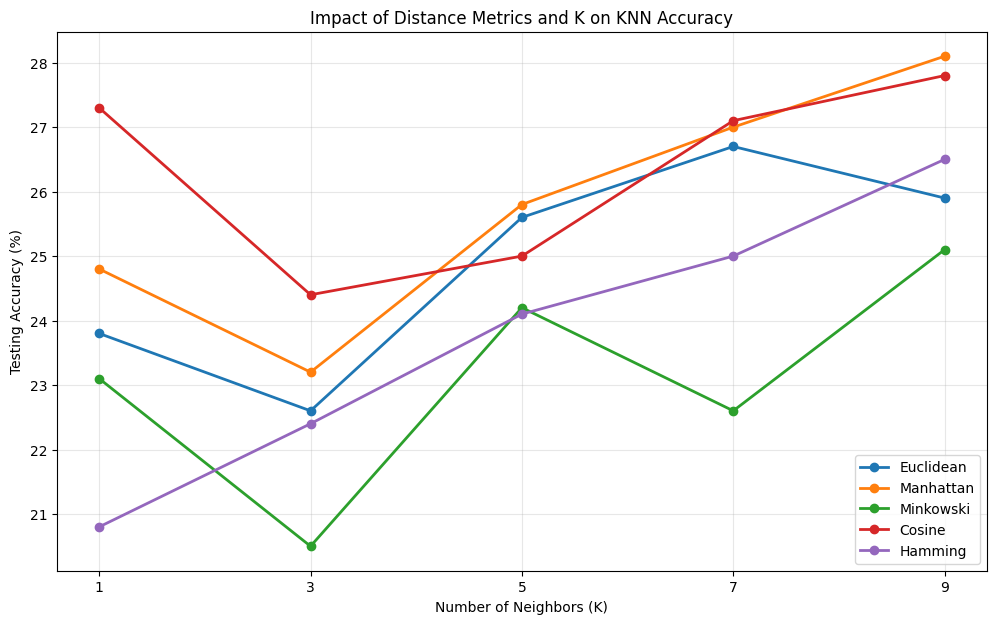

In [ ]:
plt.figure(figsize=(12, 7))

for metric_name in results:
    plt.plot(
        k_values,
        np.array(results[metric_name]) * 100,
        marker="o",
        linewidth=2,
        label=metric_name
    )

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Testing Accuracy (%)")
plt.title("Impact of Distance Metrics and K on KNN Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Find Best K + Distance**

---

Automatically find best combination

---



In [ ]:
best_accuracy = -1
best_metric = None
best_k = None

for metric_name in results:

    for i, accuracy in enumerate(results[metric_name]):

        if accuracy > best_accuracy:

            best_accuracy = accuracy
            best_metric = metric_name
            best_k = k_values[i]

print("=" * 50)
print("BEST MODEL")
print("=" * 50)

print("Best Distance Metric :", best_metric)
print("Best K               :", best_k)
print("Best Accuracy        :", round(best_accuracy * 100, 2), "%")

BEST MODEL
Best Distance Metric : Manhattan
Best K               : 9
Best Accuracy        : 28.1 %


**Confusion Matrix**

Calculate confusion matrix from scratch


In [ ]:
def confusion_matrix_manual(y_true, y_pred, num_classes=10):

    cm = np.zeros(
        (num_classes, num_classes),
        dtype=int
    )

    for actual, predicted in zip(y_true, y_pred):
        cm[actual, predicted] += 1

    return cm


best_predictions = all_predictions[
    best_metric
][best_k]

cm = confusion_matrix_manual(
    y_test_exp,
    best_predictions,
    10
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[43  2 17  0 10  1  3  4 19  1]
 [11 17 14  3 14  1 17  0 19  4]
 [22  3 48  4 10  2  7  3  1  0]
 [16  5 22 17 15  5 18  0  1  1]
 [21  5 25  2 24  1  7  3 11  1]
 [15  0 28  5 17 10 15  5  5  0]
 [13  1 31  7 19  0 25  1  3  0]
 [18  2 15  5 18  2  7 16 13  4]
 [12  4  5  0 14  3  1  1 59  1]
 [19  6 10  5  7  1  6  2 22 22]]


Visualize confusion matrix

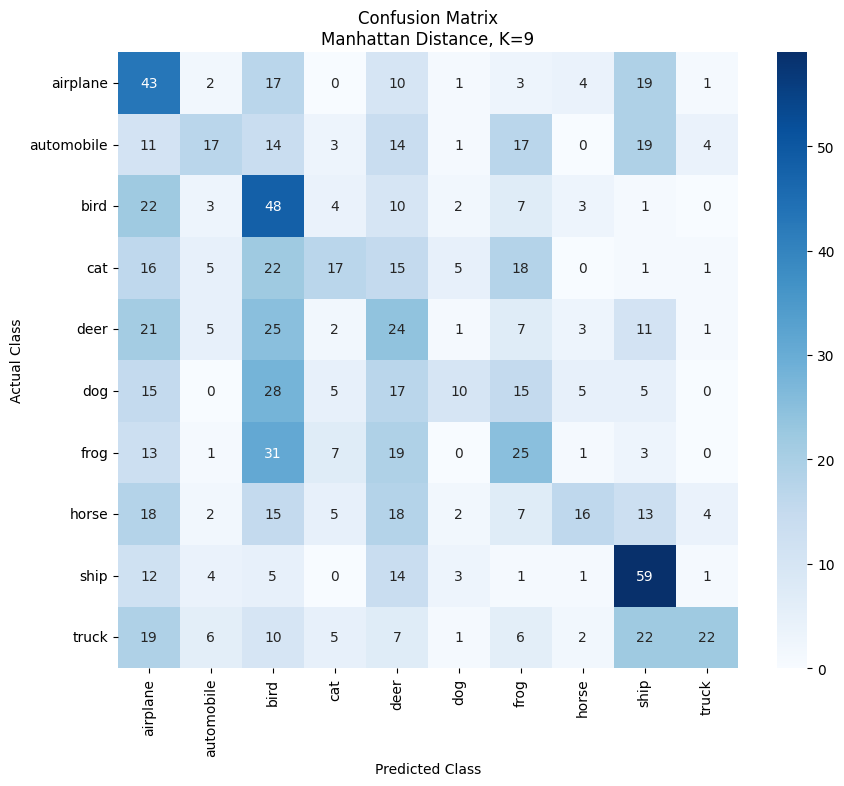

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(
    f"Confusion Matrix\n"
    f"{best_metric} Distance, K={best_k}"
)

plt.show()

                           **Precision and Recall From Scratch**

---



In [ ]:
def precision_recall_manual(cm):

    precision = []
    recall = []

    for i in range(len(cm)):

        true_positive = cm[i, i]

        false_positive = np.sum(cm[:, i]) - true_positive

        false_negative = np.sum(cm[i, :]) - true_positive

        # Precision
        if true_positive + false_positive == 0:
            p = 0
        else:
            p = true_positive / (
                true_positive + false_positive
            )

        # Recall
        if true_positive + false_negative == 0:
            r = 0
        else:
            r = true_positive / (
                true_positive + false_negative
            )

        precision.append(p)
        recall.append(r)

    return np.array(precision), np.array(recall)


precision, recall = precision_recall_manual(cm)

Display precision and recall

In [ ]:
metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall
})

metrics_df["Precision"] = metrics_df["Precision"].round(4)
metrics_df["Recall"] = metrics_df["Recall"].round(4)

display(metrics_df)

,Class,Precision,Recall
0,airplane,0.2263,0.43
1,automobile,0.3778,0.17
2,bird,0.2233,0.48
3,cat,0.3542,0.17
4,deer,0.1622,0.24
5,dog,0.3846,0.10
6,frog,0.2358,0.25
7,horse,0.4571,0.16
8,ship,0.3856,0.59
9,truck,0.6471,0.22


Average precision and recall

In [ ]:
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)

print("Best Distance Metric :", best_metric)
print("Best K               :", best_k)
print("Testing Accuracy     :", round(best_accuracy * 100, 2), "%")
print("Macro Precision      :", round(macro_precision, 4))
print("Macro Recall         :", round(macro_recall, 4))

Best Distance Metric : Manhattan
Best K               : 9
Testing Accuracy     : 28.1 %
Macro Precision      : 0.3454
Macro Recall         : 0.281


**Visualize some predictions**


In [ ]:
correct_indices = np.where(
    y_test_exp == best_predictions
)[0]

wrong_indices = np.where(
    y_test_exp != best_predictions
)[0]

print("Correct predictions:", len(correct_indices))
print("Wrong predictions  :", len(wrong_indices))

Correct predictions: 281
Wrong predictions  : 719


Display predictions

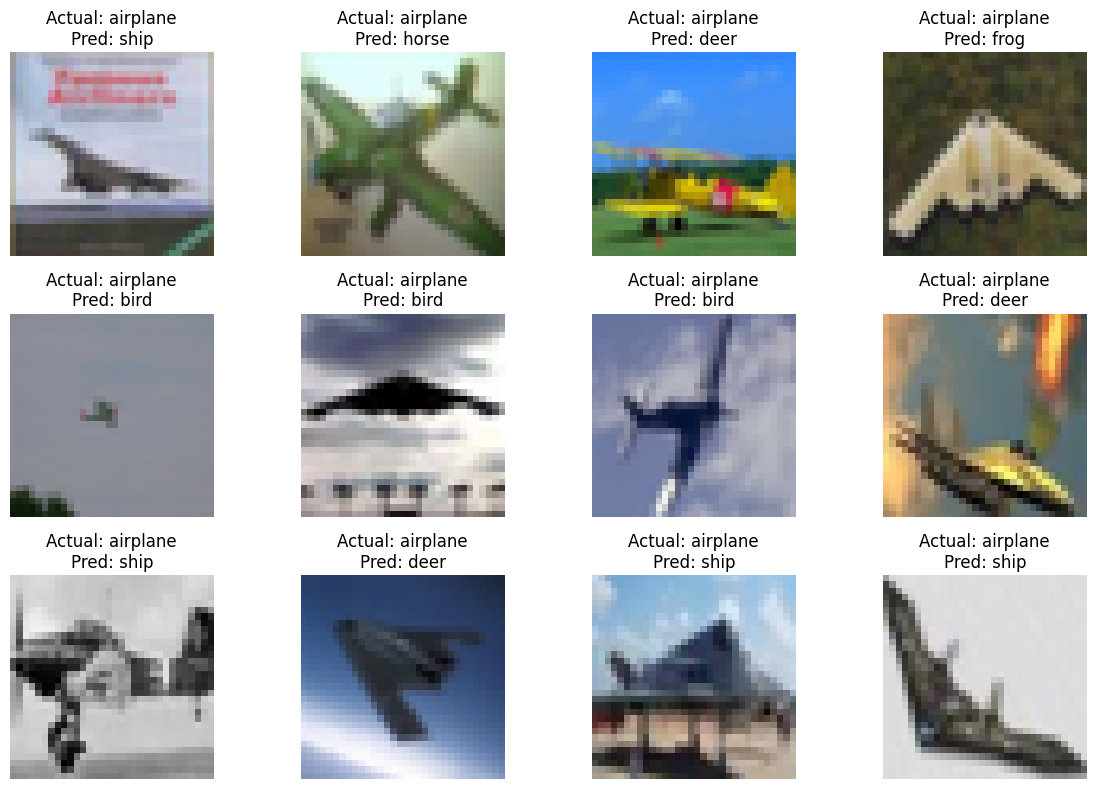

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    index = wrong_indices[i]

    # Get original CIFAR image
    original_index = np.where(
        (X_test_flat == X_test_exp[index]).all(axis=1)
    )[0][0]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[original_index])

    plt.title(
        f"Actual: {class_names[y_test_exp[index]]}\n"
        f"Pred: {class_names[best_predictions[index]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

— **Accuracy by Class**

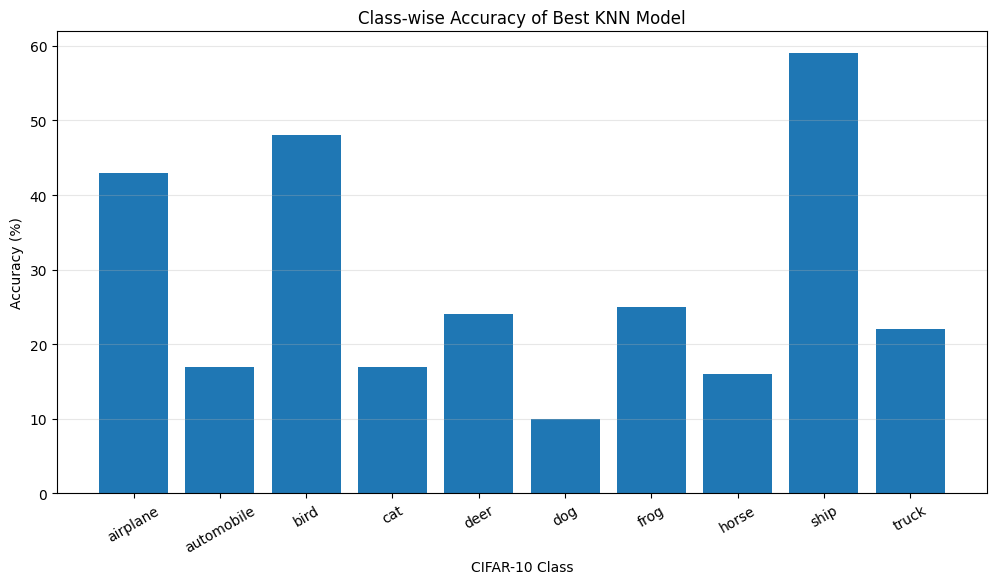

In [ ]:
class_accuracy = []

for i in range(10):

    class_indices = np.where(
        y_test_exp == i
    )[0]

    correct = np.sum(
        best_predictions[class_indices] == i
    )

    accuracy = correct / len(class_indices)

    class_accuracy.append(accuracy)


plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    np.array(class_accuracy) * 100
)

plt.xlabel("CIFAR-10 Class")
plt.ylabel("Accuracy (%)")
plt.title("Class-wise Accuracy of Best KNN Model")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()